In [21]:
import os
import sys
from sys import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
from scipy.optimize import least_squares
import json
#import extra_functions as ef
import random
#import h5py
from scripts.xcorr import helper as hp
import importlib
from scipy.interpolate import interp1d

In [22]:
def pred(coord1, coord2, start_t, end_t, pulse_idx, channel, satID):
    '''
    predicted phase given satellite
    '''
    bench_time = time.time()
    chunk_len = 30000 * (4096/250e6)
    tle_path = outils.get_tle_file(start_t, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    pulse_len_s = end_t - start_t
    d = outils.get_sat_delay_new(coord1, coord2, tle_path, start_t, pulse_len_s+1, satID)

    pulse_len_chunks = np.ceil(pulse_len_s / chunk_len)
    pulse_freq = outils.chan2freq(channel, alias=True)

    interp_chunk_times = (np.arange(pulse_len_chunks) * chunk_len)

    #get the delay values for each of these chunks
    delay = np.interp(interp_chunk_times, np.arange(len(d)), d)

    #get the predicted phase at each chunk
    pred = (-delay + delay[0]) * 2 * np.pi * pulse_freq
    print("time taken pred", time.time() - bench_time)

    return pred  

In [23]:
config_path = '/home/thomasb/albatros_analysis/scripts/orbcomm'
config_name = 'config.json'

satdet_path = '/scratch/thomasb/pulsedata_1753133403'
satdet_name = "pulsedata_1753133403_1757540615.4208999.json"

T_SPECTRA = 4096/250e6

bline_ants = set({'Antenna 1', 'Antenna 4'})

In [ ]:
antennas = []
with open(f"{config_path}/{config_name}", "r") as f:
    config = json.load(f)
    for i, (ant, details) in enumerate(config["antennas"].items()):
        ant_dict = {}
        ant_dict['name'] = details['name']
        ant_dict['coordinates'] = details['coordinates']
        ant_dict['path'] = details['path']

        if i ==0:
            ant_dict['reference'] = 'T'
        else:
            ant_dict['reference'] = 'F'

        if ant_dict['name'] in bline_ants:
            antennas.append(ant_dict)

    global_start_time = config["correlation"]["start_timestamp"]
    global_end_time = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    
nants = len(antennas)
print(antennas)
print('number of antenna:', nants)
print("Visibility Accumulation Length", v_acclen)
print('global start and end times:', global_start_time, global_end_time)

tle_path = outils.get_tle_file(global_start_time, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
chunk_length = T_SPECTRA * v_acclen

with open(f'{satdet_path}/{satdet_name}') as f:
    data = json.load(f)
    ants = data[f'{global_start_time}']
    for i, ant_from_list in enumerate(antennas):
        if ant_from_list['name'] == 'Antenna 1':
            antennas[i]['consensus_offset'] = 0
            continue
        for j, (ant_from_satdet, details) in enumerate(ants.items()):
            if ant_from_list['name'] == ant_from_satdet:
                antennas[i]['consensus_offset'] = details['consensus_offset']
                antennas[i]['pulse_data'] = details['pulse_data']

for term in antennas:
    print(term)

[{'name': 'Antenna 1', 'coordinates': [79.41718333333333, -90.76735, 189], 'path': '/scratch/mohanagr/summer_2025/baseband/mars1', 'reference': 'T'}, {'name': 'Antenna 4', 'coordinates': [79.38846667, -91.01926667, 22], 'path': '/scratch/mohanagr/summer_2025/baseband/mars4', 'reference': 'F'}]
number of antenna: 2
Visibility Accumulation Length 30000
global start and end times: 1753133403 1753140603
{'name': 'Antenna 1', 'coordinates': [79.41718333333333, -90.76735, 189], 'path': '/scratch/mohanagr/summer_2025/baseband/mars1', 'reference': 'T', 'consensus_offset': 0}
{'name': 'Antenna 4', 'coordinates': [79.38846667, -91.01926667, 22], 'path': '/scratch/mohanagr/summer_2025/baseband/mars4', 'reference': 'F', 'consensus_offset': 733645679, 'pulse_data': [{'start': 0, 'end': 305, 'sats_present': {'28654': [[1841, 'UNRELIABLE']], '25338': [[1841, 'UNRELIABLE']]}, 'individual_offset': 733646518, 'diff_to_consensus': -839}, {'start': 0, 'end': 305, 'sats_present': {'28654': [[1841, 'UNRELIA

In [25]:
info = antennas[1]
consensus_offset = info['consensus_offset']
print(consensus_offset)
observed_data = {}
desired_pulse_idx = 4

p = info['pulse_data'][desired_pulse_idx]


print(f"---------STARTING PULSE---------")
print(p)
#--------times-----

relative_start_time = p['start']
relative_end_time = p['end']
t_start = global_start_time + relative_start_time
pulse_len_s = relative_end_time - relative_start_time
t_end = t_start + pulse_len_s
pulse_len_chunks = int(np.ceil((pulse_len_s)/(T_SPECTRA * v_acclen)))
print("rel. start, end t:", relative_start_time, relative_end_time)
print("global start t:", t_start)
print("pulse len in s:", pulse_len_s)
print("pulse len in chunks:", pulse_len_chunks)

#-------other data--------
ra_path = antennas[0]['path']
print(ra_path)
nra_path = antennas[1]['path']
print(nra_path)

#----get initialized information----
files_a1, idx1 = butils.get_init_info(t_start, t_end, ra_path)
files_a2, idx2 = butils.get_init_info(t_start, t_end, nra_path)

#-------set up channels-------
channels = bdc.get_header(files_a1[0])["channels"].astype('int64')
chanstart = np.where(channels == 1834)[0][0] 
chanend = np.where(channels == 1852)[0][0]
nchans=chanend-chanstart

#--------call get_avg_fast----------
time_pulse=time.time()
pols, rowcounts, channels = hp.get_avg_fast(ra_path, 
                                            nra_path, 
                                            t_start, 
                                            t_end, 
                                            consensus_offset, 
                                            v_acclen, 
                                            pulse_len_chunks, 
                                            chanstart=chanstart, 
                                            chanend=chanend)

pulse_vis = pols[0]

print(f"DONE PULSE. TIME:", time.time()-time_pulse)

733645679
---------STARTING PULSE---------
{'start': 4585, 'end': 4815, 'sats_present': {'57166': [[1836, 'UNCLEAR'], [1837, 'RELIABLE']]}, 'individual_offset': 733645679, 'diff_to_consensus': 0}
rel. start, end t: 4585 4815
global start t: 1753137988
pulse len in s: 230
pulse len in chunks: 468
/scratch/mohanagr/summer_2025/baseband/mars1
/scratch/mohanagr/summer_2025/baseband/mars4
Not reading any data
took 1.333 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753137979.raw
took 0.877 seconds to read raw data on  /scratch/mohanagr/summer_2025/baseband/mars4/17531/1753137967.raw
before correction 549316 1281738
after correction 549316 1331773
Starting at:  549316 in filenum:  /scratch/mohanagr/summer_2025/baseband/mars1/17531/1753137979.raw for antenna 1
Starting at:  1331773 in filenum:  /scratch/mohanagr/summer_2025/baseband/mars4/17531/1753137967.raw for antenna 2
ACCLEN RECEIVED IS 30000
took 0.052 seconds to read raw data on  /scratch/mohanagr/sum

['57166']
[[(0.005340682342648506+0.01246148906648159j)
  (-0.0017801625654101372+0.003455742262303829j)
  (-0.021467138081789017+0.005340563599020243j) ...
  (-0.018744438886642456-0.016229601576924324j)
  (0.004293481819331646+0.00973889697343111j)
  (-0.0036651596892625093+0.0028274303767830133j)]
 [(-0.021362029016017914+0.0043982258066535j)
  (-0.023350831121206284-0.014555903151631355j)
  (0.006073642987757921-0.009424722753465176j) ...
  (-0.030262719839811325-0.002408490050584078j)
  (-0.0048170736990869045-0.0016755154356360435j)
  (0.0015707951970398426-0.014765345491468906j)]
 [(0.01267098169773817-0.006178376264870167j)
  (0.017801402136683464-0.005235659424215555j)
  (0.0006283171242102981+0.02701679617166519j) ...
  (0.003979274537414312-0.006283166352659464j)
  (0.005445178598165512-0.011098457500338554j)
  (-0.0070158205926418304+0.002408544532954693j)]
 ...
 [(0.026178818196058273-0.008168106898665428j)
  (-0.013822815380990505+0.009633976966142654j)
  (0.0077491444535

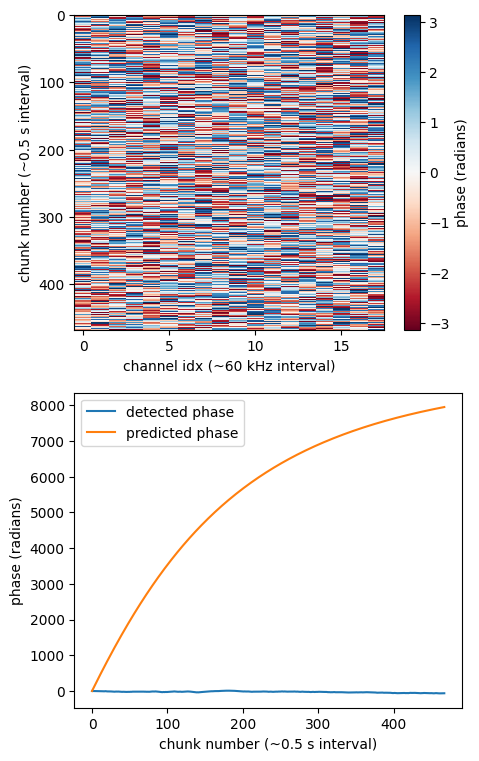

In [26]:
pulse_info = antennas[1]['pulse_data'][desired_pulse_idx]
start, end = pulse_info['start'] + global_start_time, pulse_info['end'] + global_start_time
sats = list(pulse_info['sats_present'].keys())
print(sats)

print(pulse_vis)
p_vis = np.angle(pulse_vis)
amp = np.abs(pulse_vis)
print(amp)

chanlist = np.arange(1834, 1852)

mean_amp = []
for i in range(18):
    m = np.mean(amp[:,i])
    print(m)
    mean_amp.append(m)
chan_small_idx = np.where(mean_amp == np.max(mean_amp))[0][0]

print(chan_small_idx)
chan_big_idx = chanlist[chan_small_idx]
print(chan_big_idx)

phase = np.unwrap(p_vis[:,chan_small_idx]) - p_vis[0, chan_small_idx]
diff = np.diff(phase)

for sat in sats:
    bench = 10e9
    pr = pred(antennas[0]['coordinates'],
                antennas[1]['coordinates'],
                start,
                end,
                desired_pulse_idx, 
                chan_big_idx,
                int(sat))[:len(phase)]
    res = np.linalg.norm(phase - pr)
    if res < bench:
        pred_phase = pr
import matplotlib.pyplot as plt


fig, ax = plt.subplots(2, 1, figsize=(5, 9))

im = ax[0].imshow(p_vis, aspect='auto', cmap='RdBu', interpolation='none')
ax[0].set_xlabel("channel idx (~60 kHz interval)")
ax[0].set_ylabel("chunk number (~0.5 s interval)")
cbar = fig.colorbar(im, ax=ax[0], orientation='vertical')
cbar.set_label("phase (radians)")

ax[1].plot(phase, label='detected phase')
ax[1].plot(pred_phase, label='predicted phase')
ax[1].set_xlabel("chunk number (~0.5 s interval)")
ax[1].set_ylabel("phase (radians)")
ax[1].legend()

plt.show()
